In [1]:
%pip install datasets pandas

from datasets import load_dataset
import pandas as pd
from pathlib import Path


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\phuce\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SENTIMENT_LABELS = {0: "negative", 1: "neutral", 2: "positive"}
TOPIC_LABELS = {0: "lecturer", 1: "training_program", 2: "facility", 3: "others"}

In [3]:
OUTPUT_DIR = Path("../processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
ds = load_dataset("uitnlp/vietnamese_students_feedback", revision="refs/convert/parquet")

In [5]:
for split in ["train", "validation", "test"]:
    df = ds[split].to_pandas()
    df["sentiment"] = df["sentiment"].map(SENTIMENT_LABELS)
    df["topic"] = df["topic"].map(TOPIC_LABELS)
    out_path = OUTPUT_DIR / f"{split}.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved {split} -> {out_path} ({len(df)} rows)")

Saved train -> ..\processed\train.csv (11426 rows)
Saved validation -> ..\processed\validation.csv (1583 rows)
Saved test -> ..\processed\test.csv (3166 rows)


In [8]:
train = pd.read_csv("../processed/train.csv")
val = pd.read_csv("../processed/validation.csv")
test = pd.read_csv("../processed/test.csv")

=== Sentiment distribution (toàn bộ) ===
sentiment
positive    8038
negative    7439
neutral      698
Name: count, dtype: int64
sentiment
positive    0.497
negative    0.460
neutral     0.043
Name: proportion, dtype: float64


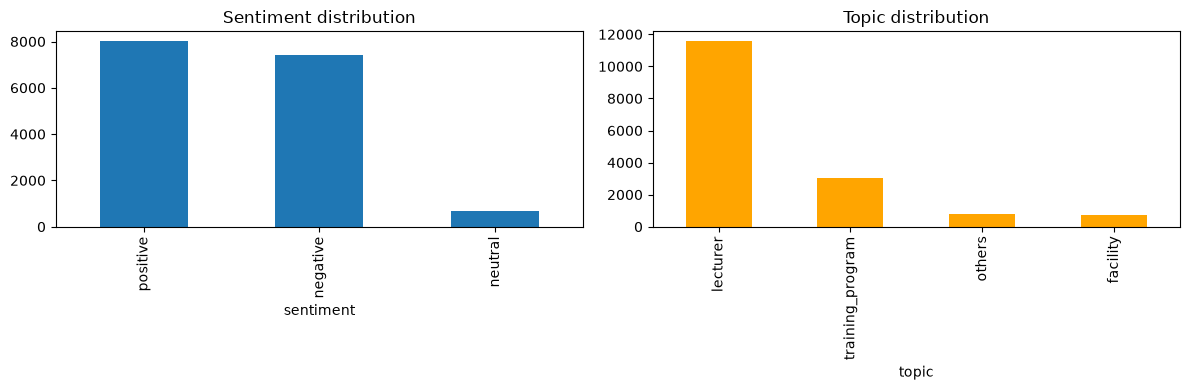


=== Sentiment theo split ===
sentiment   negative  neutral  positive
split                                  
test           0.445    0.053     0.502
train          0.466    0.040     0.494
validation     0.445    0.046     0.509

=== Topic distribution (toàn bộ) ===
topic
lecturer            11607
training_program     3040
others                816
facility              712
Name: count, dtype: int64

=== Sentiment x Topic ===
topic      facility  lecturer  others  training_program
sentiment                                              
negative        681      4105     325              2328
neutral          13       292     231               162
positive         18      7210     260               550

=== Độ dài câu (số từ) ===
count    16175.000000
mean        14.229181
std         10.103769
min          2.000000
25%          8.000000
50%         11.000000
75%         17.000000
max        161.000000
Name: n_words, dtype: float64


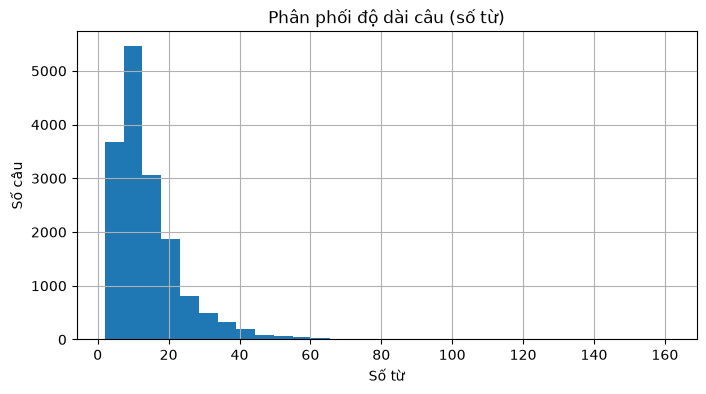


=== Ví dụ mỗi tổ hợp sentiment x topic ===
[positive / training_program] (550 câu): có bài tập rõ ràng .
[positive / lecturer] (7210 câu): giảng viên nhiệt tình , phương pháp giảng dạy dễ hiểu .
[positive / others] (260 câu): em thấy việc này khá bổ ích .
[positive / facility] (18 câu): phòng thực hành tốt .
[negative / training_program] (2328 câu): tăng thêm thời lượng môn học .
[negative / lecturer] (4105 câu): thầy còn khó tính và để học sinh tự tìm hiểu hơi nhiều , nhiều chỗ thầy dạy hơi khó hiểu .
[negative / others] (325 câu): chưa từng gặp giảng viên wzjwz144 ở môn thực hành thiết bị mạng và truyền thông đa phương tiện .
[negative / facility] (681 câu): đề nghị nhà trường có thêm phòng lab để sinh viên học phần nghe được dễ dàng và có hiệu quả hơn !
[neutral / training_program] (162 câu): môn học này chất lượng bình thường .
[neutral / lecturer] (292 câu): thầy hay đi trễ nhưng không nhiều , chỉ 15 phút mỗi ngày .
[neutral / others] (231 câu): em không có ý kiến gì .
[neutral /

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Gộp cả 3 split để xem tổng thể, có thêm cột đánh dấu split
train["split"] = "train"
val["split"] = "validation"
test["split"] = "test"
full = pd.concat([train, val, test], ignore_index=True)

# 1. Phân phối sentiment
print("=== Sentiment distribution (toàn bộ) ===")
print(full["sentiment"].value_counts())
print(full["sentiment"].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
full["sentiment"].value_counts().plot(kind="bar", ax=axes[0], title="Sentiment distribution")
full["topic"].value_counts().plot(kind="bar", ax=axes[1], title="Topic distribution", color="orange")
plt.tight_layout()
plt.show()

# 2. Phân phối sentiment theo từng split (check có lệch giữa train/val/test không)
print("\n=== Sentiment theo split ===")
print(pd.crosstab(full["split"], full["sentiment"], normalize="index").round(3))

# 3. Phân phối topic
print("\n=== Topic distribution (toàn bộ) ===")
print(full["topic"].value_counts())

# 4. Cross-tab sentiment x topic
print("\n=== Sentiment x Topic ===")
print(pd.crosstab(full["sentiment"], full["topic"]))

# 5. Độ dài câu (số từ)
full["n_words"] = full["sentence"].str.split().str.len()
print("\n=== Độ dài câu (số từ) ===")
print(full["n_words"].describe())

plt.figure(figsize=(8, 4))
full["n_words"].hist(bins=30)
plt.title("Phân phối độ dài câu (số từ)")
plt.xlabel("Số từ")
plt.ylabel("Số câu")
plt.show()

# 6. Vài câu ví dụ mỗi tổ hợp sentiment x topic
print("\n=== Ví dụ mỗi tổ hợp sentiment x topic ===")
for sent in full["sentiment"].unique():
    for top in full["topic"].unique():
        subset = full[(full["sentiment"] == sent) & (full["topic"] == top)]
        if len(subset) > 0:
            example = subset.sample(1, random_state=42)["sentence"].values[0]
            print(f"[{sent} / {top}] ({len(subset)} câu): {example}")

In [10]:
import pandas as pd

samples = []

# 1. Bao phủ đều 3 sentiment x 4 topic (12 tổ hợp), ưu tiên lấy hết các tổ hợp hiếm (facility, neutral)
for sent in full["sentiment"].unique():
    for top in full["topic"].unique():
        subset = full[(full["sentiment"] == sent) & (full["topic"] == top)]
        if len(subset) == 0:
            continue
        n_take = min(3, len(subset))  # lấy tối đa 3 câu/tổ hợp, tổ hợp hiếm có bao nhiêu lấy hết
        samples.append(subset.sample(n_take, random_state=42))

sample_df = pd.concat(samples).drop_duplicates(subset="sentence")

# 2. Bổ sung thêm vài câu dài (>40 từ) để test câu phức tạp
long_sentences = full[full["n_words"] > 40].sample(5, random_state=1)
sample_df = pd.concat([sample_df, long_sentences]).drop_duplicates(subset="sentence")

# 3. Bổ sung câu có dấu hiệu phủ định (chứa "không", "chưa", "chẳng")
negation_mask = full["sentence"].str.contains(r"\bkhông\b|\bchưa\b|\bchẳng\b", case=False, na=False)
negation_samples = full[negation_mask].sample(5, random_state=2)
sample_df = pd.concat([sample_df, negation_samples]).drop_duplicates(subset="sentence")

sample_df = sample_df.sample(frac=1, random_state=0).reset_index(drop=True)  # xáo trộn thứ tự
print(f"Tổng số mẫu: {len(sample_df)}")

# Thêm cột trống để 2 người điền tay
sample_df["negation"] = ""
sample_df["sarcasm_or_implication"] = ""
sample_df["multi_aspect"] = ""
sample_df["difficulty_note"] = ""

sample_df.to_csv("../processed/manual_sample_40_50.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file mẫu để 2 người điền tay")

Tổng số mẫu: 46
Đã lưu file mẫu để 2 người điền tay
